In [3]:
# Notebook 1: Images are Numbers
# You'll learn: pixels, channels, arrays, and a first camera frame.

import numpy as np
import matplotlib.pyplot as plt
import cv2

print("numpy:", np.__version__)
print("opencv:", cv2.__version__)

numpy: 2.0.2
opencv: 4.10.0


shape: (3, 4)
dtype: uint8
min/max: 0 170


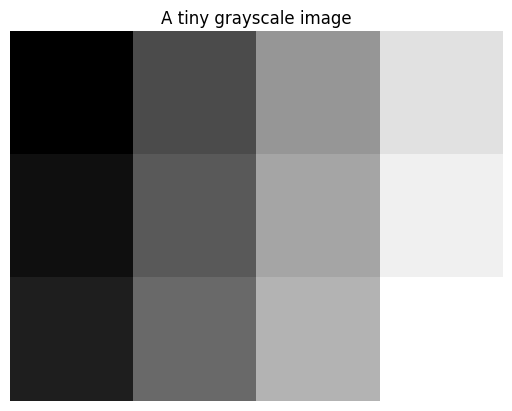

In [4]:
# A tiny 3x4 "image" with 1 channel (grayscale)
img = np.array([
    [0,  50, 100, 150],
    [10, 60, 110, 160],
    [20, 70, 120, 170]
], dtype=np.uint8)

print("shape:", img.shape)   # (height, width)
print("dtype:", img.dtype)
print("min/max:", img.min(), img.max())

plt.imshow(img, cmap="gray")
plt.title("A tiny grayscale image")
plt.axis("off")
plt.show()

In [5]:
!pwd

/Users/quentin/Desktop/NoBlackBoxes/LastBlackBox/course/versions/ai-workshops/02_vision/_resources/notebooks


OpenCV loads BGR images by default.
shape (H,W,C): (746, 744, 3)
dtype: uint8


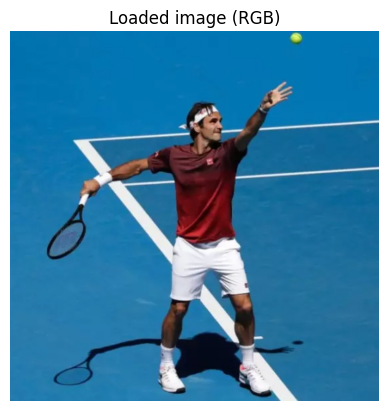

In [6]:
# Put an image file next to this notebook, e.g. "sample.jpg"
path = "../pictures/sample.jpg"
bgr = cv2.imread(path)

if bgr is None:
    raise FileNotFoundError(
        f"Couldn't load {path}. Put an image next to the notebook (e.g. sample.jpg)."
    )

print("OpenCV loads BGR images by default.")
print("shape (H,W,C):", bgr.shape)
print("dtype:", bgr.dtype)

rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

plt.imshow(rgb)
plt.title("Loaded image (RGB)")
plt.axis("off")
plt.show()

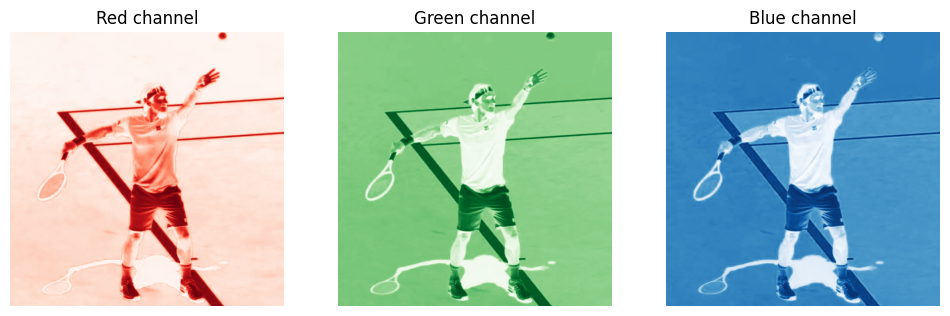

In [7]:
R = rgb[:, :, 0]
G = rgb[:, :, 1]
B = rgb[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(R, cmap="Reds"); axes[0].set_title("Red channel"); axes[0].axis("off")
axes[1].imshow(G, cmap="Greens"); axes[1].set_title("Green channel"); axes[1].axis("off")
axes[2].imshow(B, cmap="Blues"); axes[2].set_title("Blue channel"); axes[2].axis("off")
plt.show()

gray shape: (746, 744)


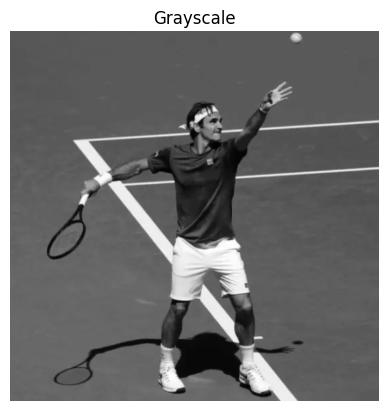

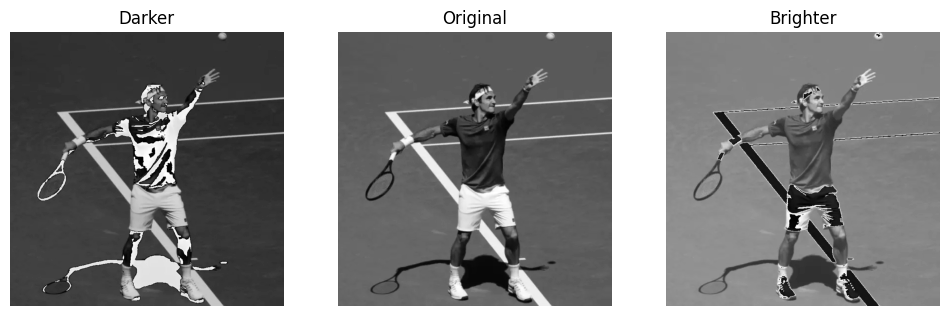

In [8]:
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

print("gray shape:", gray.shape)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")
plt.show()

# Brightness change (clipped to 0..255)
brighter = np.clip(gray + 40, 0, 255).astype(np.uint8)
darker = np.clip(gray - 40, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(darker, cmap="gray"); axes[0].set_title("Darker"); axes[0].axis("off")
axes[1].imshow(gray, cmap="gray"); axes[1].set_title("Original"); axes[1].axis("off")
axes[2].imshow(brighter, cmap="gray"); axes[2].set_title("Brighter"); axes[2].axis("off")
plt.show()

In [ ]:
# Did you notice how some pixels got brighter in the "darker" image, even though we subtracted values? Similarly, did you notice how some got darker in the "brighter" image? 
# Remember, pixel values are represented by unsigned 8-bit integers (uint8), meaning they only contain values between 0-255. If we try to represent a value less than 0 like this, then the values cannot be accurate. What happens is something called "underflow" when trying to go below 0 and "overflow" when trying to go above 255. The values "wrap around" to the other side so that they always stay within the range capable of being represented by uint8.

# Th below demonstrates this:

# Display the grayscale values
print(f"Grayscale values: min: {gray.min()}, max: {gray.max()}")

# Subtract 40 from the grayscale values
shifted_down_uint8 = gray - 40

# Due to underflow, the values that were originally less than 40 will wrap around and become large values close to 255. Thus, the range of the shifted_down_uint8 will still be between 0 and 255.
print(f"Shifted down values: min: {shifted_down_uint8.min()}, max: {shifted_down_uint8.max()}")

# To avoid this, we can convert the image to another data type before performing the subtraction, and then clip the values to the correct range before converting back to uint8:
shifted_down = np.clip(gray.astype(np.float32) - 40, 0, 255).astype(np.uint8)

# Now, we can see the values are correctly shifted down and we've avoided underflow:
print(f"Shifted down values (with clipping): min: {shifted_down.min()}, max: {shifted_down.max()}")

Grayscale values: min: 1, max: 255
Shifted down values: min: 0, max: 255
Shifted down values (with clipping): min: 0, max: 215


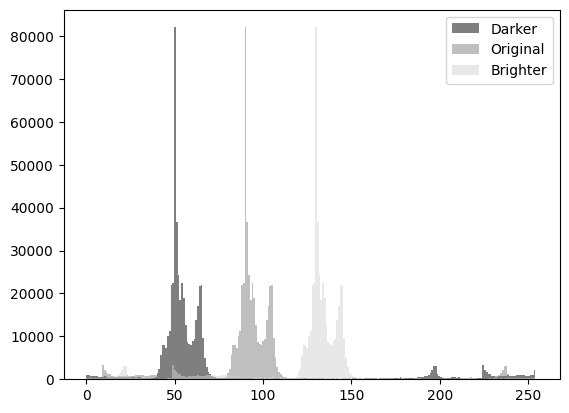

In [23]:
# We can look at the distribution of pixel values by counting the number of pixels at each intensity level (0..255) BEFORE and AFTER brightness change.

plt.hist(darker.ravel(), bins=256, range=(0, 255), color="black", alpha=0.5, label="Darker")
# plt.hist(shifted_down.ravel(), bins=256, range=(0, 255), color="red", alpha=0.5, label="Accounting for Underflow")
plt.hist(gray.ravel(), bins=256, range=(0, 255), color="gray", alpha=0.5, label="Original")
plt.hist(brighter.ravel(), bins=256, range=(0, 255), color="lightgray", alpha=0.5, label="Brighter")
plt.legend()
plt.show()

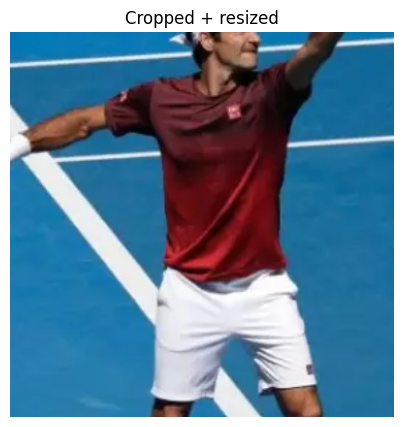

In [9]:
h, w = rgb.shape[:2]
crop = rgb[h//4: 3*h//4, w//4: 3*w//4]  # center crop

resized = cv2.resize(crop, (w//2, h//2), interpolation=cv2.INTER_AREA)

plt.figure(figsize=(5,5))
plt.imshow(resized)
plt.title("Cropped + resized")
plt.axis("off")
plt.show()

[0:04:07.945078157] [2069]  INFO Camera camera_manager.cpp:340 libcamera v0.6.0+rpt20251202
[0:04:08.097731652] [2072]  INFO IPAProxy ipa_proxy.cpp:180 Using tuning file /usr/share/libcamera/ipa/rpi/vc4/imx708.json
[0:04:08.117189908] [2072]  INFO Camera camera_manager.cpp:223 Adding camera '/base/soc/i2c0mux/i2c@1/imx708@1a' for pipeline handler rpi/vc4
[0:04:08.117552598] [2072]  INFO RPI vc4.cpp:445 Registered camera /base/soc/i2c0mux/i2c@1/imx708@1a to Unicam device /dev/media2 and ISP device /dev/media0
[0:04:08.117820532] [2072]  INFO RPI pipeline_base.cpp:1111 Using configuration file '/usr/share/libcamera/pipeline/rpi/vc4/rpi_apps.yaml'
Mode selection for 2304:1296:12:P
    SRGGB10_CSI2P,1536x864/0 - Score: 3400
    SRGGB10_CSI2P,2304x1296/0 - Score: 1000
    SRGGB10_CSI2P,4608x2592/0 - Score: 1900
[0:04:08.211271012] [2069]  INFO Camera camera.cpp:1215 configuring streams: (0) 2304x1296-YUV420/sYCC (1) 2304x1296-SBGGR10_CSI2P/RAW
[0:04:08.212364101] [2072]  INFO RPI vc4.cpp:62

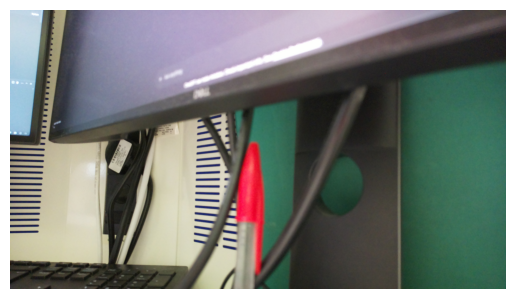

In [8]:
import subprocess
import cv2
import matplotlib.pyplot as plt

try:
    subprocess.run([
        "rpicam-still",
        "-o", "pictures/captured_frame.png",
        "--timeout", "200",
        "--nopreview"
    ], check=True)

    img = cv2.imread("captured_frame.png")

    if img is None:
        print("Image capture failed.")
    else:
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(rgb)
        plt.axis("off")
        plt.show()

except Exception as e:
    print("Camera failed but notebook continues:", e)

Saved: pictures/captured_frame_red_filtered.png


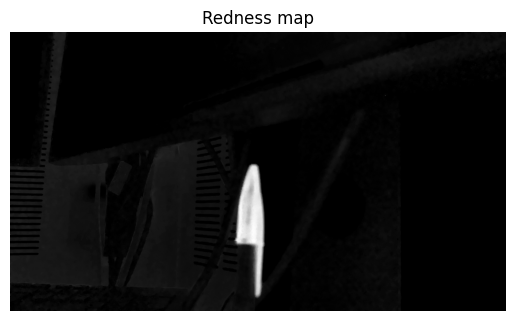

In [9]:
try:
    R = rgb[:, :, 0].astype(float)
    G = rgb[:, :, 1].astype(float)
    B = rgb[:, :, 2].astype(float)

    redness = R - 0.5 * (G + B)
    redness = redness.clip(0, 255).astype("uint8")

    output_path = "pictures/captured_frame_red_filtered.png"
    cv2.imwrite(output_path, redness)

    print("Saved:", output_path)

    plt.imshow(redness, cmap="gray")
    plt.title("Redness map")
    plt.axis("off")
    plt.show()

except Exception as e:
    print("Redness map failed but notebook continues:", e)